# Binomial p-value overflow — raw per-record comparison

| method | mechanism |
|---|---|
| **current** | effective-N=site (production): deflate N to # independent climates (355 pools -> ~31 sites). This is the one with the overflow. |
| **betabinom** | beta-binomial, per-chromosome Williams-moment-estimated overdispersion rho + K=16 LFMM factors |
| **quasibinom** | per-variant quasi-binomial: Pearson dispersion phi scales the Wald z, + K=16 |

(A 4th candidate, ACER-style effective-N using sequencing coverage, was dropped:
kMate estimates AF from founder-haplotype deconvolution, not per-locus read
counting, so coverage isn't the right precision bottleneck for it — its
near-1 GIF was likely an artifact of over-penalizing via an inapplicable
assumption. betabinom/quasibinom estimate overdispersion empirically from the
data itself, so they don't have that problem.)

Below: QQ plot and genome-wide Manhattan of the **raw per-record p-values**
(MAF>=0.05, pre-WZA-aggregation) for all 3 methods, so the overflow is visible
directly at the source, not after block aggregation. A WZA-level summary table
(BH counts, core-block survival) follows for reference.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

CLQ = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/phase1_replication/clq90"
FIX = f"{CLQ}/binom_fix_test"
CLASSES = ["snp", "nonsnp"]
METHODS = ["current", "betabinom", "quasibinom"]
METHOD_LABEL = {"current": "current (eff-N=site, HAS OVERFLOW)", "betabinom": "beta-binomial+K16",
                "quasibinom": "quasi-binomial+K16"}
CHROMS = [f"Chr{i}" for i in range(1, 6)]
Q_FLOOR = 1e-16
CORE_BLOCKS = {"Chr1_2343": "GAPC2", "Chr4_6307": "CRK13-16", "Chr3_6144": "AT3G30320",
               "Chr1_6539": "NAC014"}
COLORS = {"current": "#7f7f7f", "betabinom": "#1f77b4", "quasibinom": "#2ca02c"}

# NOTE: "current" here = the ORIGINAL eff-N=site binomial (the one this comparison
# was decided against). It has since been REPLACED in production by quasibinom, so
# the live clq90/wza_in + clq90/wza binomial files are now quasibinom — point
# "current" at the archived eff-N=site copies so this comparison stays reproducible.
ARCH = f"{CLQ}/archive_binomial_effNsite_pre_quasibinom_20260703"
RAW_PATH = {
    "current":    lambda cls: f"{ARCH}/wza_in/binomial_{cls}_gen9_bio1.csv",
    "betabinom":  lambda cls: f"{FIX}/betabinom/betabinom_{cls}_gen9_bio1.csv",
    "quasibinom": lambda cls: f"{FIX}/quasibinom/quasibinom_{cls}_gen9_bio1.csv",
}
WZA_PATH = {
    "current":    lambda cls: f"{ARCH}/wza/wza_binomial_{cls}_gen9_bio1_deg2.csv",
    "betabinom":  lambda cls: f"{FIX}/betabinom/wza/wza_betabinom_{cls}_gen9_bio1_deg2.csv",
    "quasibinom": lambda cls: f"{FIX}/quasibinom/wza/wza_binomial_{cls}_gen9_bio1.csv",
}

def load_raw(method, cls):
    d = pd.read_csv(RAW_PATH[method](cls), usecols=["chrom", "pos", "MAF", "pval"])
    d = d[(d.MAF >= 0.05) & d.chrom.astype(str).isin(CHROMS)].copy()
    d["chrom"] = d["chrom"].astype(str)
    return d

def gif(p):
    p = np.asarray(p, float); p = p[np.isfinite(p) & (p > 0)]
    return float(np.median(chi2.isf(p, 1)) / chi2.ppf(0.5, 1))

def bh_q(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p); q = np.empty(n)
    q[order] = (p[order] * n) / (np.arange(n) + 1)
    q[order] = np.minimum.accumulate(q[order][::-1])[::-1]
    return np.clip(q, 0, 1)

def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0
    return k, (q * k / m if k else np.nan)

def load_wza(method, cls):
    w = pd.read_csv(WZA_PATH[method](cls)).rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna() & w["chrom"].astype(str).isin(CHROMS)].copy()
    w["chrom"] = w["chrom"].astype(str)
    w["q"] = bh_q(w["Z_pVal"].to_numpy())
    w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=Q_FLOOR))
    return w

# shared genome x-axis (from raw per-record positions, full chrom extent)
allpos = pd.concat([load_raw("current", c)[["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6
offset, off = {}, 0.0
for c in CHROMS:
    offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}

print("loaded raw:", {(m, c): len(load_raw(m, c)) for m in METHODS for c in CLASSES})

loaded raw: {('current', 'snp'): 1205512, ('current', 'nonsnp'): 413044, ('betabinom', 'snp'): 1205512, ('betabinom', 'nonsnp'): 413044, ('quasibinom', 'snp'): 1205512, ('quasibinom', 'nonsnp'): 413044}


## QQ plot (raw per-record p, calibration)

Classic QQ: expected vs observed -log10(p) under the null. The current model's
GIF is still ~8-9 even after the effective-N=site fix; beta/quasi-binomial pull
it in substantially.

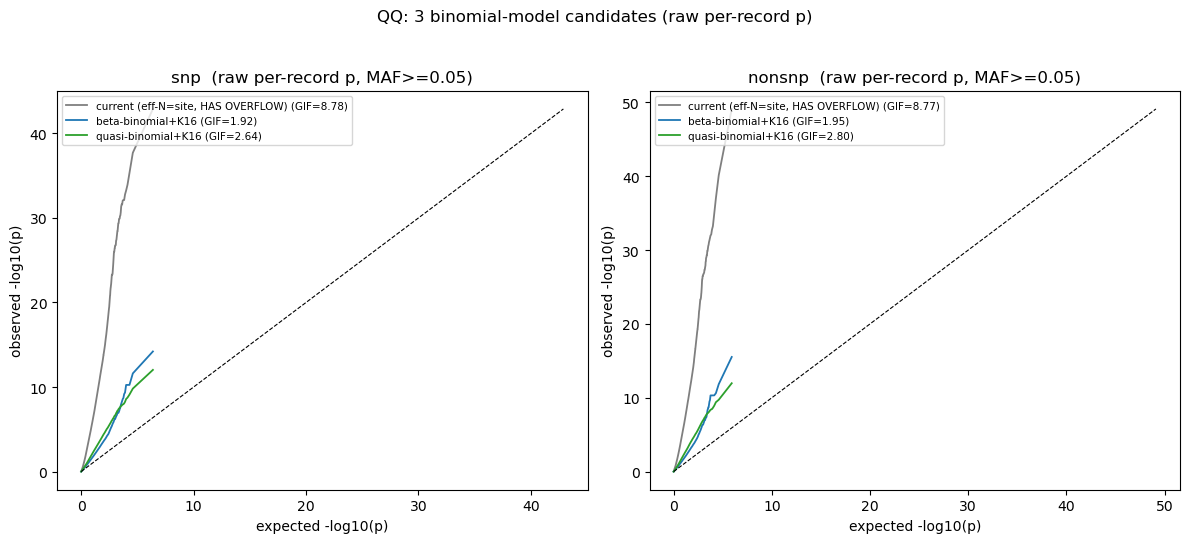

In [2]:
def qq_points(p, maxn=40000):
    p = np.sort(np.asarray(p, float)); p = p[np.isfinite(p) & (p > 0)]
    n = len(p)
    exp = -np.log10((np.arange(1, n + 1) - 0.5) / n)
    obs = -np.log10(np.clip(p, 1e-320, 1))
    if n > maxn:
        idx = np.unique(np.r_[np.linspace(0, n - 1, maxn).astype(int), np.arange(n - 300, n)])
        exp, obs = exp[idx], obs[idx]
    return exp, obs

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, cls in zip(axes, CLASSES):
    mx = 0
    for method in METHODS:
        p = load_raw(method, cls)["pval"].to_numpy()
        ex, ob = qq_points(p)
        ax.plot(ex, ob, color=COLORS[method], lw=1.3,
                label=f"{METHOD_LABEL[method]} (GIF={gif(p):.2f})")
        mx = max(mx, ex.max(), ob.max())
    ax.plot([0, mx], [0, mx], "k--", lw=0.8)
    ax.set_xlabel("expected -log10(p)"); ax.set_ylabel("observed -log10(p)")
    ax.set_title(f"{cls}  (raw per-record p, MAF>=0.05)")
    ax.legend(fontsize=7.5, loc="upper left")
fig.suptitle("QQ: 3 binomial-model candidates (raw per-record p)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f"{FIX}/qq_binomial_fix_compare.png", dpi=140, bbox_inches="tight")
plt.show()

## Raw per-record Manhattan (pre-WZA-aggregation)

One point per variant, y = -log10(raw model p), MAF>=0.05. This is what actually
feeds WZA — compare the current model's pileup at the ceiling against
beta/quasi-binomial's much more contained tail.

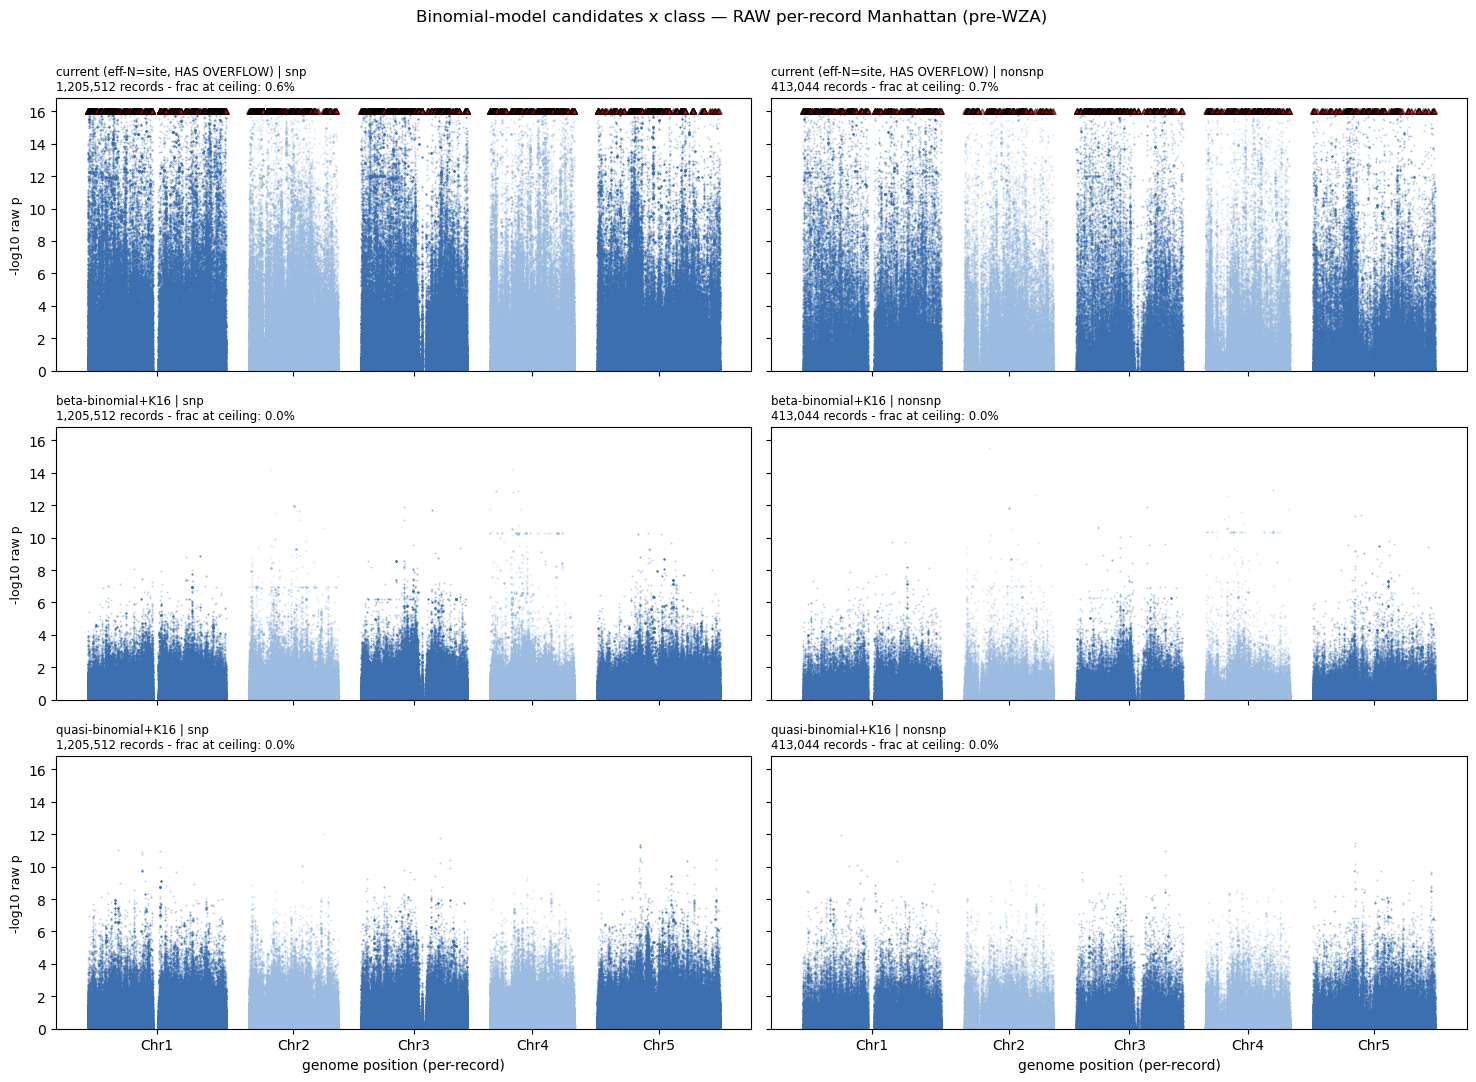

In [3]:
RAW_YMAX = -np.log10(Q_FLOOR)

fig, axes = plt.subplots(len(METHODS), len(CLASSES), figsize=(15, 11), sharex=True, sharey=True)
for r, method in enumerate(METHODS):
    for cc, cls in enumerate(CLASSES):
        ax = axes[r, cc]
        d = load_raw(method, cls).copy()
        d["x"] = d["pos"] + d["chrom"].map(offset)
        d["mlogp"] = -np.log10(d["pval"].clip(lower=Q_FLOOR))
        n = len(d)
        y = d["mlogp"].clip(upper=RAW_YMAX)
        ofs = d["pval"] < Q_FLOOR          # true floor-hits, BEFORE clipping (not mlogp>RAW_YMAX,
                                            # which can never be true since mlogp is already clipped)
        for c in CHROMS:
            m = (d["chrom"] == c) & ~ofs
            ax.scatter(d["x"][m], y[m], s=2, c=chrom_col[c], alpha=.3, linewidths=0,
                       rasterized=True)
        if ofs.any():
            ax.scatter(d["x"][ofs], np.full(int(ofs.sum()), RAW_YMAX), marker="^", s=14,
                       color="red", edgecolor="k", zorder=6, alpha=.5)
        frac_ceiling = float(ofs.mean())
        ax.set_title(f"{METHOD_LABEL[method]} | {cls}\n{n:,} records - "
                     f"frac at ceiling: {frac_ceiling:.1%}", fontsize=8.5, loc="left")
        if cc == 0:
            ax.set_ylabel("-log10 raw p", fontsize=9)
        ax.set_ylim(0, RAW_YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS)
    ax.set_xlabel("genome position (per-record)")
fig.suptitle("Binomial-model candidates x class — RAW per-record Manhattan (pre-WZA)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{FIX}/manhattan_raw_binomial_fix_compare.png", dpi=130, bbox_inches="tight")
plt.show()

## For reference: WZA-level summary (BH counts, core-block survival)

Not plotted here (see the earlier WZA Manhattan grid if you want it) — just the
numbers behind the decision.

In [4]:
rows = []
for method in METHODS:
    for cls in CLASSES:
        raw = load_raw(method, cls)
        w = load_wza(method, cls)
        nbh, _ = bh_count_crit(w["Z_pVal"])
        core_sig = {blk: bool((w.loc[w.block == blk, "q"] < 0.05).any()) for blk in CORE_BLOCKS}
        rows.append(dict(method=method, cls=cls, n_records=len(raw), gif=round(gif(raw["pval"]), 2),
                         frac_p05=round(float((raw["pval"] < 0.05).mean()), 3),
                         n_blocks=len(w), n_bh=nbh, **{f"sig_{b}": core_sig[b] for b in CORE_BLOCKS}))
summary = pd.DataFrame(rows)
summary

,method,cls,n_records,gif,frac_p05,n_blocks,n_bh,sig_Chr1_2343,sig_Chr4_6307,sig_Chr3_6144,sig_Chr1_6539
0,current,snp,1205512,8.78,0.508,57587,50,True,True,True,True
1,current,nonsnp,413044,8.77,0.508,42677,33,True,True,True,False
2,betabinom,snp,1205512,1.92,0.160,57587,43,False,False,True,False
3,betabinom,nonsnp,413044,1.95,0.164,42677,8,False,False,True,False
4,quasibinom,snp,1205512,2.64,0.230,57587,35,False,False,True,False
5,quasibinom,nonsnp,413044,2.80,0.241,42677,27,False,False,True,False
